In [54]:
import pandas as pd

In [78]:
data_dump = pd.read_csv("./output/TEST/full_data_dump.csv")
data_dump.head()

,id,query,ground_truths,status,entities,relations,results,grounding_candidates,vss_merged_candidates
0,6517,Which cell structures are involved in interact...,"[56241, 55842, 56174, 56263]",IN_PROGRESS,"{""A"": {""type"": [""drug""], ""lexical"": {""name"": ""...","{('A', 'B'): ['target', 'enzyme', 'transporter...","{'answer_list': [56174, 55522, 56241, 55842, 5...","[56174, 55522, 56241, 55842, 56263, 55635, 564...","[56174, 55522, 56241, 55842, 56263, 55635, 564..."
1,9996,Which genes or proteins are expressed exclusiv...,[10833],IN_PROGRESS,"{""A"": {""type"": [""anatomy""], ""lexical"": {""name""...","{('A', 'ANSWER'): ['expression present'], ('B'...","{'answer_list': [61, 2773, 3387, 1403, 704, 13...","[61, 2773, 3387, 1403, 704, 13628, 1532, 10833...","[61, 2773, 3387, 1403, 704, 13628, 1532, 10833..."
2,3630,Could you suggest any medications effective fo...,[15179],IN_PROGRESS,"{""A"": {""type"": [""disease""], ""lexical"": {""name""...","{('A', 'ANSWER'): ['indication'], ('B', 'ANSWE...","{'answer_list': [14982, 15441, 15570, 14137, 1...","[14982, 15441, 15570, 14137, 15534, 15099, 153...","[14982, 15441, 15570, 14137, 15534, 15099, 153..."
3,10252,Which gene or protein responsible for coding t...,"[43, 2140]",IN_PROGRESS,"{""A"": {""type"": [""gene/protein"", ""molecular_fun...","{('A', 'ANSWER'): ['associated with', 'interac...","{'answer_list': [43, 9451, 2140, 11474, 7756, ...","[43, 9451, 2140, 11474, 7756, 11496, 7284, 485...","[43, 9451, 2140, 11474, 7756, 11496, 7284, 485..."
4,5142,Which autosomal dominant diseases are linked t...,[30638],IN_PROGRESS,"{""A"": {""type"": [""anatomy""], ""lexical"": {""name""...","{('A', 'ANSWER'): ['linked to', 'associated wi...","{'answer_list': [], 'answer_set': set(), 'grou...",[],"[38395, 30638, 32617, 38422, 29485, 30770, 381..."


In [79]:
for col in ["grounding_candidates", "ground_truths", "vss_merged_candidates"]:
    data_dump[col] = data_dump[col].apply(lambda x: [int(y) for y in x.lstrip('[').rstrip(']').split(",") if y!=''] if pd.notna(x) else [])

In [80]:
data_dump.head()

stats = {
    # "query_id": [],
    "num_gts": [],
    "retirved_gts": [],
    "grounding_gts": [],
    "vss_gts": [],
    "lost_gts": []
}

for _, row in data_dump.iterrows():

    num_gts = len(row.ground_truths)
    print(row.ground_truths, len(row.ground_truths))
    retirved_gts = len(set(row.vss_merged_candidates).intersection(set(row.ground_truths)))
    grounding_gts =  len(set(row.grounding_candidates).intersection(set(row.ground_truths)))
    vss_gts = len(set(row.vss_merged_candidates[12:]).intersection(set(row.ground_truths)))
    lost_gts = len(set(row.grounding_candidates[12:]).intersection(set(row.ground_truths)) - set(row.vss_merged_candidates[12:]))

    # stats["query_id"].append(row.id)
    stats["num_gts"].append(num_gts)
    stats["retirved_gts"].append(retirved_gts)
    stats["grounding_gts"].append(grounding_gts)
    stats["vss_gts"].append(vss_gts)
    stats["lost_gts"].append(lost_gts)

[56241, 55842, 56174, 56263] 4
[10833] 1
[15179] 1
[43, 2140] 2
[30638] 1
[62592] 1
[59232] 1
[52067, 53456, 46931, 40628, 103931] 5
[18223] 1
[14330, 14505, 14508, 14512, 14522, 14141] 6
[111] 1
[99105, 99106, 99107, 33271, 99109, 30376, 31629, 99247, 94839, 27609] 10
[31754, 27547, 38252] 3
[45193, 47627, 50011, 103928, 112264] 5
[94418, 94210, 94316] 3
[27831] 1
[29113] 1
[8034, 57603, 61258, 61259, 61260, 61261, 8878, 61262, 61263, 61264, 61265, 61266, 61267, 61268, 61269, 5874, 57658, 701] 18
[24225, 23564, 22757, 22759] 4
[63952, 64778, 63235, 64876] 4
[13664, 11205, 6887, 5448, 3145, 3147, 11641, 5884, 765] 9
[37440] 1
[96249, 96941] 2
[23162, 23915] 2
[108356, 44625, 106193, 103667, 46101, 42615, 111482, 48219, 112316] 9
[16019] 1
[94307, 22349, 22335] 3
[111] 1
[14558] 1
[39750] 1
[32731] 1
[14844] 1
[15572] 1
[31517] 1
[27434] 1
[9967] 1
[66747, 64863, 64876, 63824, 64512] 5
[14313] 1
[63952, 63826] 2
[2017, 5098, 1004, 8432, 3774] 5
[30035] 1
[5843] 1
[31427] 1
[36119] 1
[56

In [81]:
df = pd.DataFrame(stats)


In [82]:
df.head()

,num_gts,retirved_gts,grounding_gts,vss_gts,lost_gts
0,4,4,4,0,0
1,1,1,1,0,0
2,1,0,1,0,1
3,2,2,2,0,0
4,1,1,0,0,0


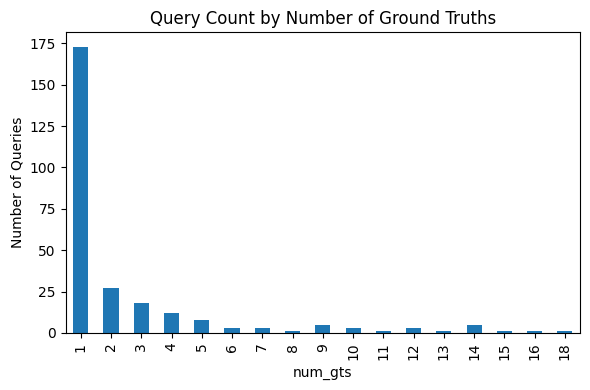

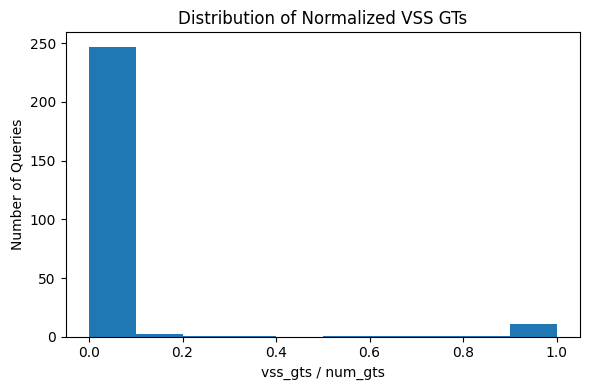

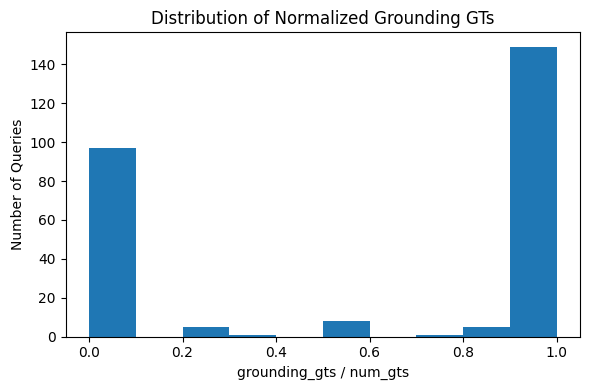

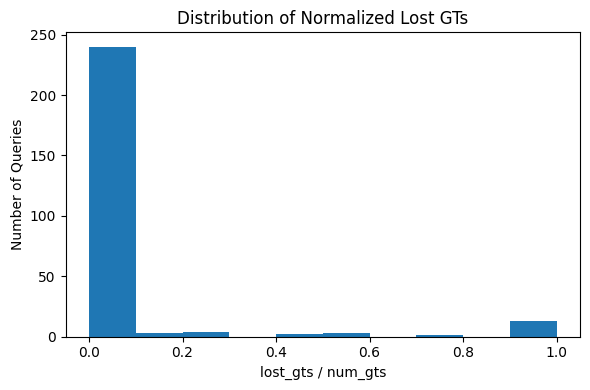

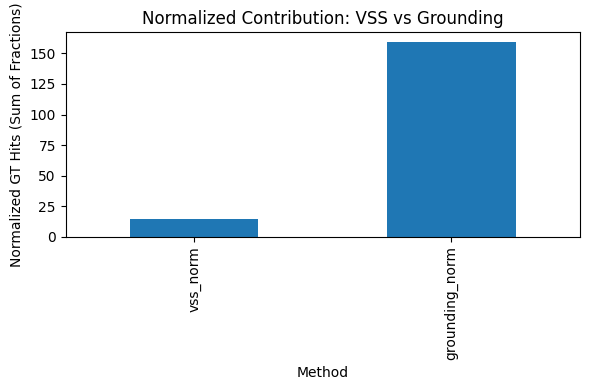

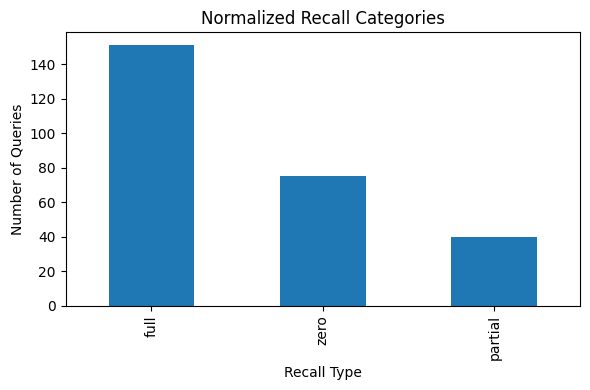

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# df already created from your stats dictionary
df["vss_norm"] = df["vss_gts"] / df["num_gts"]
df["grounding_norm"] = df["grounding_gts"] / df["num_gts"]
df["lost_norm"] = df["lost_gts"] / df["num_gts"]
df["retrieved_norm"] = df["retirved_gts"] / df["num_gts"]

plt.figure(figsize=(6,4))
df.groupby("num_gts").size().plot(kind="bar")
plt.title("Query Count by Number of Ground Truths")
plt.xlabel("num_gts")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2.
# -----------------------------------------------------
plt.figure(figsize=(6,4))
df["vss_norm"].plot(kind="hist", bins=10)
plt.title("Distribution of Normalized VSS GTs")
plt.xlabel("vss_gts / num_gts")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))
df["grounding_norm"].plot(kind="hist", bins=10)
plt.title("Distribution of Normalized Grounding GTs")
plt.xlabel("grounding_gts / num_gts")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df["lost_norm"].plot(kind="hist", bins=10)
plt.title("Distribution of Normalized Lost GTs")
plt.xlabel("lost_gts / num_gts")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. Contribution of VSS and Grounding in retrieved GTs
# -----------------------------------------------------
plt.figure(figsize=(6,4))
(df[["vss_norm", "grounding_norm"]].sum()).plot(kind="bar")
plt.title("Normalized Contribution: VSS vs Grounding")
plt.xlabel("Method")
plt.ylabel("Normalized GT Hits (Sum of Fractions)")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 4. Count of queries with full, zero, and partial recall
# -----------------------------------------------------
    
def recall_type_norm(row):
    if row["retrieved_norm"] == 0:
        return "zero"
    if row["retrieved_norm"] == 1:
        return "full"
    return "partial"

df["recall_type_norm"] = df.apply(recall_type_norm, axis=1)
plt.figure(figsize=(6,4))
df["recall_type_norm"].value_counts().plot(kind="bar")
plt.title("Normalized Recall Categories")
plt.xlabel("Recall Type")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()


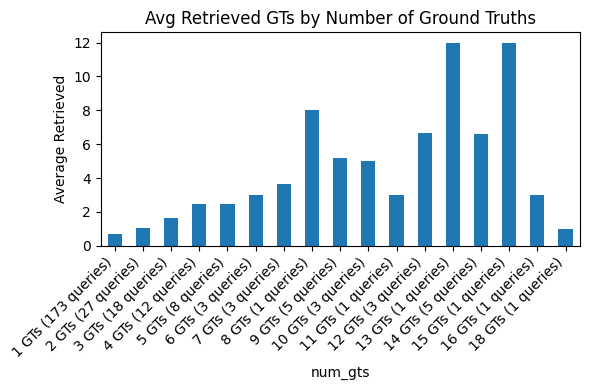

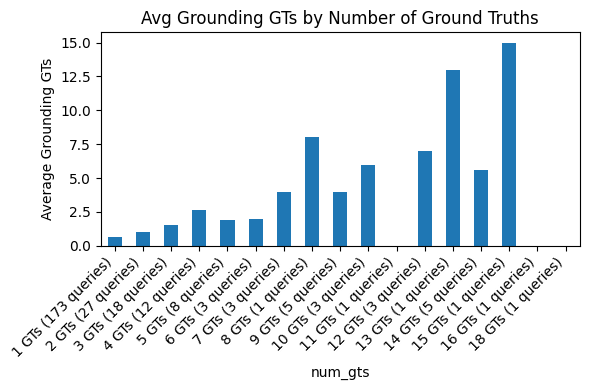

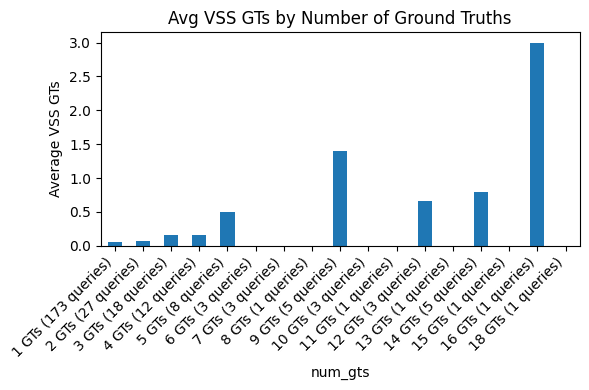

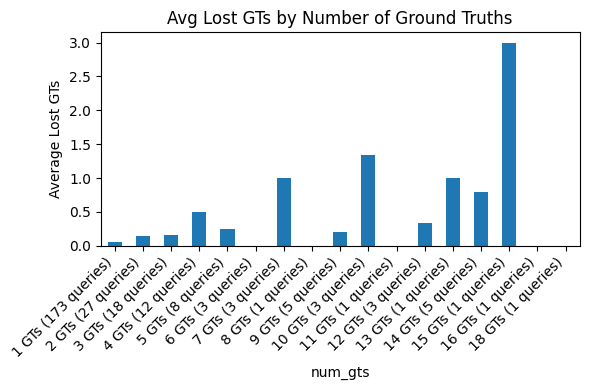

In [84]:
# Group by num_gts and compute mean, sum, etc.
agg_df = df.groupby("num_gts").agg({
    "retirved_gts": ["mean", "sum"],
    "grounding_gts": ["mean", "sum"],
    "vss_gts": ["mean", "sum"],
    "lost_gts": ["mean", "sum"],
    "num_gts": "count"  # number of queries in each group
})

# Query counts
query_counts = df.groupby("num_gts").size()
agg_df["query_count"] = query_counts
tick_labels = [f"{gt} GTs ({cnt} queries)" for gt, cnt in zip(query_counts.index, query_counts.values)]


plt.figure(figsize=(6,4))
agg_df["retirved_gts"]["mean"].plot(kind="bar")
plt.title("Avg Retrieved GTs by Number of Ground Truths")
plt.xlabel("num_gts")
plt.ylabel("Average Retrieved")

plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))
agg_df["grounding_gts"]["mean"].plot(kind="bar")
plt.title("Avg Grounding GTs by Number of Ground Truths")
plt.xlabel("num_gts")
plt.ylabel("Average Grounding GTs")

plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))
agg_df["vss_gts"]["mean"].plot(kind="bar")
plt.title("Avg VSS GTs by Number of Ground Truths")
plt.xlabel("num_gts")
plt.ylabel("Average VSS GTs")

plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))
agg_df["lost_gts"]["mean"].plot(kind="bar")
plt.title("Avg Lost GTs by Number of Ground Truths")
plt.xlabel("num_gts")
plt.ylabel("Average Lost GTs")

plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [85]:
len(df[df["lost_gts"] > 0])

28

In [86]:
len(df[(df["lost_gts"] > 0) & (df["num_gts"] > 1) & (df["retirved_gts"] >= 1) ]) 

14

In [87]:
len(df[(df["lost_gts"] > 0) & (df["num_gts"] > 1) & (df["retirved_gts"] == 0) ]) 

3